# Where Ontology Similarity and Text-Embedding Similarity Disagree

For a sample of term pairs in each of several ontologies, we compute two similarities:

- **ontology similarity**: Jaccard similarity of the two terms' `is_a` ancestor sets
  (the `closure` model in OAK);
- **text similarity**: cosine similarity of the terms' LLM embeddings, as served by OLS.

Most pairs fall along a common trend. The interesting cases are in the **corners**,
where the two measures disagree:

- **ontology-similar, text-dissimilar**: terms that are close in the hierarchy but
  described in different words (e.g. synonyms the model doesn't know, or terms grouped by
  a logical criterion that their names don't reflect);
- **text-similar, ontology-dissimilar**: terms that read alike but are classified far
  apart (e.g. a shared word with different meanings, or the same concept modelled in two
  places, which may point to a modelling problem in the ontology).

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="eutils")
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt
import seaborn as sns

# reference palette (categorical slots in fixed order; sequential blue ramp)
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "font.size": 10, "axes.titlesize": 11, "figure.dpi": 110,
})
SEQUENTIAL = sns.blend_palette(["#f0efec", "#86b6ef", "#2a78d6", "#0d366b"], as_cmap=True)

In [2]:
import random

import numpy as np
import pandas as pd

from oaklib import get_adapter
from oaklib.datamodels.vocabulary import IS_A, OWL_CLASS

MODEL = "text-embedding-3-large_pca512"
ONTOLOGIES = {"hp": "HP", "mondo": "MONDO", "go": "GO", "cl": "CL"}
N_RELATED, N_RANDOM, N_SHOW = 300, 100, 8

## Sampling pairs

Purely random pairs are almost all unrelated, so they would pile up in one corner. To
cover the whole range of ontology similarity, most pairs are sampled by picking a term,
moving up to a random one of its ancestors, then down to a random descendant of that
ancestor. A smaller number of fully random pairs is added. Only terms from the ontology's
own namespace are used (no imported terms) and obsolete terms are excluded.

In [3]:
def sample_pairs(adapter, prefix, seed=0):
    rng = random.Random(seed)
    terms = sorted(t for t in adapter.entities(filter_obsoletes=True, owl_type=OWL_CLASS)
                   if t.startswith(prefix + ":"))
    term_set = set(terms)
    pairs = set()
    while len(pairs) < N_RELATED:
        a = rng.choice(terms)
        ancs = [x for x in adapter.ancestors(a, predicates=[IS_A], reflexive=False) if x in term_set]
        if not ancs:
            continue
        x = rng.choice(ancs)
        descs = [d for d in adapter.descendants(x, predicates=[IS_A], reflexive=False)
                 if d in term_set and d != a]
        if descs:
            pairs.add(tuple(sorted((a, rng.choice(descs)))))
    while len(pairs) < N_RELATED + N_RANDOM:
        a, b = rng.sample(terms, 2)
        pairs.add(tuple(sorted((a, b))))
    return sorted(pairs)

adapters, pair_sets = {}, {}
for name, prefix in ONTOLOGIES.items():
    adapters[name] = (get_adapter(f"sqlite:obo:{name}"), get_adapter(f"ols:{name}"))
    pair_sets[name] = sample_pairs(adapters[name][0], prefix)
    print(name, len(pair_sets[name]), "pairs")

hp 400 pairs


mondo 400 pairs


go 400 pairs


cl 400 pairs


## Scoring

Closure vectors are computed in one call per ontology so that they share dimensions; text
vectors come from OLS and are cached locally.

In [4]:
from oaklib.utilities.embeddings.closure_embeddings import closure_embeddings

def most_specific_common_ancestor(adapter, a, b):
    common = set(adapter.ancestors(a, predicates=[IS_A])) & set(adapter.ancestors(b, predicates=[IS_A]))
    common.discard("owl:Thing")
    if not common:
        return None
    return max(common, key=lambda c: len(list(adapter.ancestors(c, predicates=[IS_A]))))

frames = []
for name, (onto, ols) in adapters.items():
    pairs = pair_sets[name]
    terms = sorted({t for p in pairs for t in p})
    ids, _, C = closure_embeddings(onto, terms)
    cix = {t: i for i, t in enumerate(ids)}
    tids, T = ols.entity_embeddings(terms, model=MODEL)
    T = T / np.linalg.norm(T, axis=1, keepdims=True)
    tix = {t: i for i, t in enumerate(tids)}
    rows = []
    for a, b in pairs:
        if a not in tix or b not in tix:
            continue
        x, y = C[cix[a]] > 0, C[cix[b]] > 0
        rows.append({"ontology": name, "a": a, "b": b,
                     "ontology_sim": (x & y).sum() / (x | y).sum(),
                     "text_sim": float(T[tix[a]] @ T[tix[b]])})
    df = pd.DataFrame(rows)
    # disagreement: difference of within-ontology percentile ranks
    df["disagreement"] = df.ontology_sim.rank(pct=True) - df.text_sim.rank(pct=True)
    frames.append(df)
    print(f"{name}: {len(df)} pairs scored ({len(pairs) - len(df)} missing a text embedding)")
scores = pd.concat(frames, ignore_index=True)

hp: 400 pairs scored (0 missing a text embedding)


mondo: 400 pairs scored (0 missing a text embedding)


go: 400 pairs scored (0 missing a text embedding)


cl: 400 pairs scored (0 missing a text embedding)


## The scatter plots

Each point is a pair. The **disagreement** score is the difference between a pair's
percentile rank under ontology similarity and its percentile rank under text similarity.
The 8 most extreme pairs in each direction are highlighted and numbered; the tables below
list them.

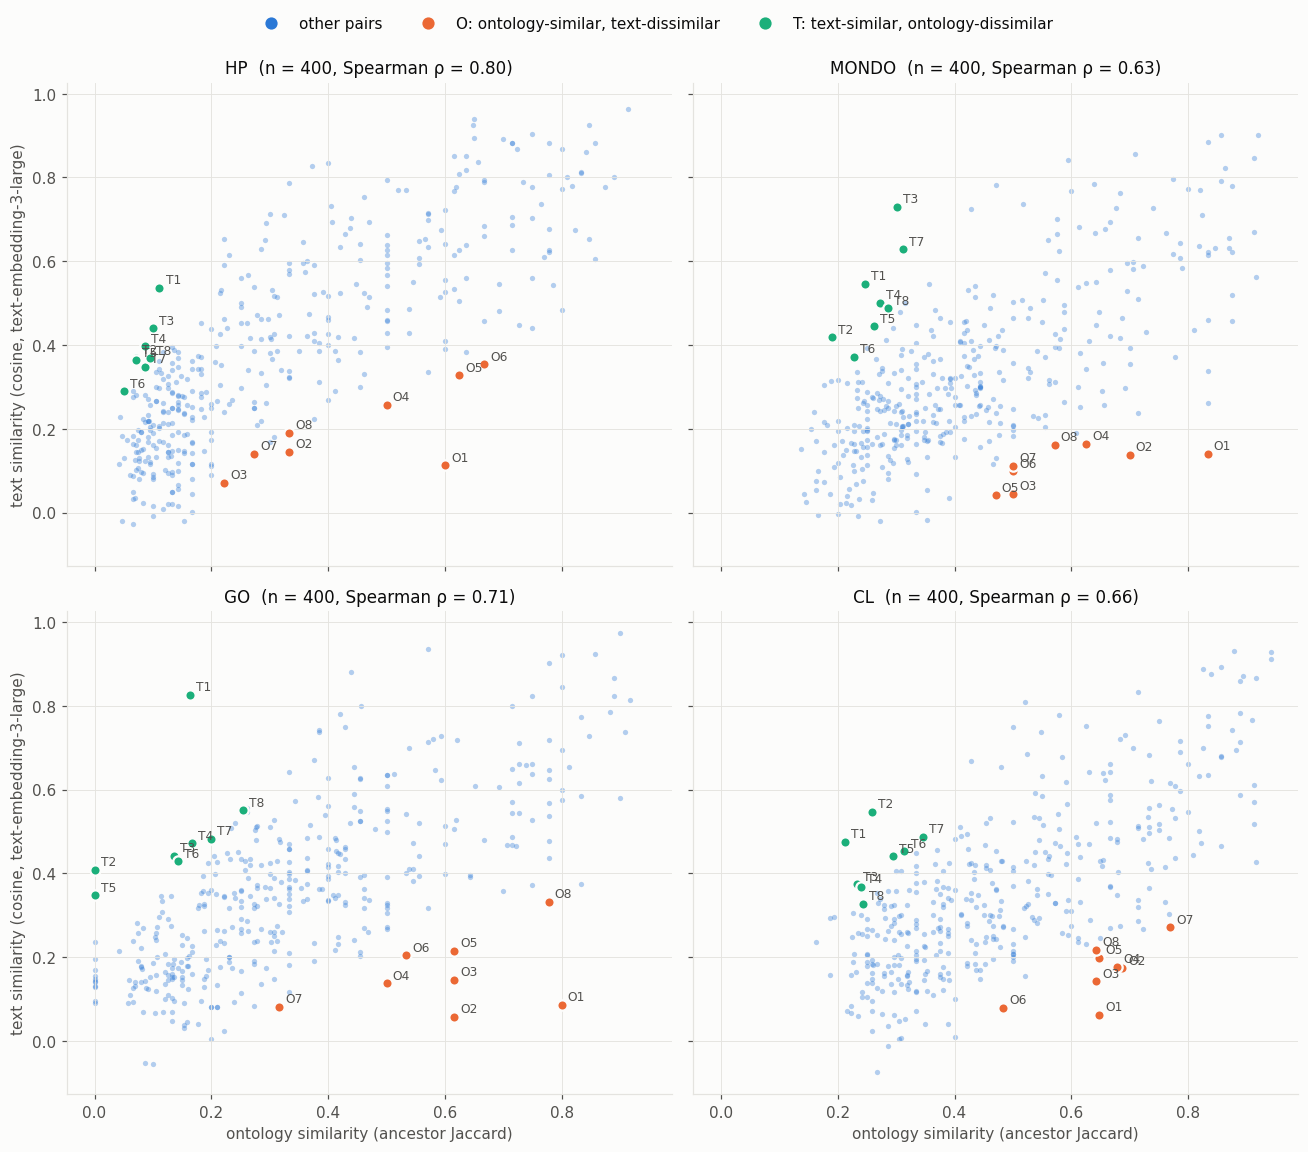

In [5]:
from scipy.stats import spearmanr

ONTO_ONLY, TEXT_ONLY = ORANGE, AQUA
corners = {}
fig, axes = plt.subplots(2, 2, figsize=(12, 10.5), sharex=True, sharey=True)
for ax, (name, df) in zip(axes.flat, scores.groupby("ontology", sort=False)):
    onto_only = df.nlargest(N_SHOW, "disagreement")
    text_only = df.nsmallest(N_SHOW, "disagreement")
    corners[name] = (onto_only, text_only)
    rest = df.drop(onto_only.index.union(text_only.index))
    ax.scatter(rest.ontology_sim, rest.text_sim, s=12, color=BLUE, alpha=0.35, linewidths=0)
    for sub, color, tag in ((onto_only, ONTO_ONLY, "O"), (text_only, TEXT_ONLY, "T")):
        ax.scatter(sub.ontology_sim, sub.text_sim, s=46, color=color, edgecolors=SURFACE, linewidths=1.5, zorder=3)
        for k, (_, r) in enumerate(sub.iterrows(), 1):
            ax.annotate(f"{tag}{k}", (r.ontology_sim, r.text_sim), xytext=(4, 3),
                        textcoords="offset points", fontsize=8, color=INK2)
    rho = spearmanr(df.ontology_sim, df.text_sim).statistic
    ax.set_title(f"{name.upper()}  (n = {len(df)}, Spearman ρ = {rho:.2f})")
for ax in axes[-1]:
    ax.set_xlabel("ontology similarity (ancestor Jaccard)")
for ax in axes[:, 0]:
    ax.set_ylabel(f"text similarity (cosine, {MODEL.replace('_pca512', '')})")
handles = [plt.Line2D([], [], marker="o", linestyle="", color=c, markersize=7) for c in (BLUE, ONTO_ONLY, TEXT_ONLY)]
fig.legend(handles, ["other pairs", "O: ontology-similar, text-dissimilar", "T: text-similar, ontology-dissimilar"],
           loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.0))
fig.tight_layout(rect=(0, 0, 1, 0.965))

## The corners

For each ontology, the two tables list the most extreme disagreements. "Common ancestor"
is the most specific shared `is_a` ancestor, which shows how far apart the ontology places
the two terms.

In [6]:
from IPython.display import Markdown, display

pd.set_option("display.max_colwidth", 60)

def corner_table(onto, sub, tag):
    labels = dict(onto.labels(set(sub.a) | set(sub.b)))
    out = []
    for k, (_, r) in enumerate(sub.iterrows(), 1):
        mica = most_specific_common_ancestor(onto, r.a, r.b)
        out.append({
            "#": f"{tag}{k}",
            "term 1": f"{labels.get(r.a)} ({r.a})",
            "term 2": f"{labels.get(r.b)} ({r.b})",
            "ontology sim": round(r.ontology_sim, 2),
            "text sim": round(r.text_sim, 2),
            "common ancestor": onto.label(mica) if mica else "(none)",
        })
    return pd.DataFrame(out).set_index("#")

for name, (onto_only, text_only) in corners.items():
    onto = adapters[name][0]
    display(Markdown(f"### {name.upper()}: ontology-similar, text-dissimilar"))
    display(corner_table(onto, onto_only, "O"))
    display(Markdown(f"### {name.upper()}: text-similar, ontology-dissimilar"))
    display(corner_table(onto, text_only, "T"))

### HP: ontology-similar, text-dissimilar

,term 1,term 2,ontology sim,text sim,common ancestor
#,,,,,
O1,Contiguous gene syndrome (HP:0001466),Imprinted (HP:0034338),0.60,0.11,Inheritance qualifier
O2,Ameliorated by (HP:0025254),Multiple-finger involvement (HP:6001122),0.33,0.14,Clinical modifier
O3,Posterior fossa localization (HP:0430129),Exacerbated by exposure to sunlight (HP:6001075),0.22,0.07,Clinical modifier
O4,Microscopic hematuria (HP:0002907),Waxy casts (HP:0031202),0.50,0.26,Abnormal urine cytology
O5,Blue-field entoptic phenomenon (HP:0020331),Difficulty adjusting to changes in luminance (HP:0030512),0.62,0.33,Abnormality of vision
O6,Conus terminalis arteriovenous malformation (HP:0031939),Spinal cord granuloma (HP:6000257),0.67,0.35,Abnormal spinal cord morphology
O7,Exercise-triggered malignant hyperthermia (HP:0034732),Mucus in stool (HP:6000686),0.27,0.14,Abnormality of metabolism/homeostasis
O8,Tapered tooth (HP:0033781),Lip hyperpigmentation (HP:0100816),0.33,0.19,Abnormal oral morphology


### HP: text-similar, ontology-dissimilar

,term 1,term 2,ontology sim,text sim,common ancestor
#,,,,,
T1,Undermodelled hand bones (HP:0004292),Complete duplication of the proximal phalanx of the 3rd ...,0.11,0.54,Abnormality of limbs
T2,Absent phalangeal crease (HP:0006109),Unilateral perisylvian polymicrogyria (HP:0032406),0.07,0.37,Phenotypic abnormality
T3,Almond-shaped palpebral fissure (HP:0007874),Congruous homonymous hemianopia (HP:0030518),0.10,0.44,Phenotypic abnormality
T4,Abnormal stapes morphology (HP:0008628),Fractured carpal bone (HP:0041248),0.09,0.40,Phenotypic abnormality
T5,Abnormality of the periorbital region (HP:0000606),Carpal bone aplasia (HP:0004231),0.07,0.36,Phenotypic abnormality
T6,Short middle phalanx of the 2nd toe (HP:0010435),Abnormal hypopharynx morphology (HP:3000053),0.05,0.29,Phenotypic abnormality
T7,Premature adrenarche (HP:0012412),Preterm intraventricular hemorrhage (HP:0030747),0.09,0.35,Phenotypic abnormality
T8,Cholestatic liver disease (HP:0002611),Choroidal hemangioma (HP:0007872),0.10,0.37,Phenotypic abnormality


### MONDO: ontology-similar, text-dissimilar

...

,term 1,term 2,ontology sim,text sim,common ancestor
#,,,,,
T1,negative regulation of dendritic spine development (GO:0...,positive regulation of dendritic spine morphogenesis (GO...,0.16,0.83,regulation of dendritic spine development
T2,integrin alpha9-beta1 complex (GO:0034679),negative regulation of fibronectin-dependent thymocyte m...,0.00,0.41,(none)
T3,protein localization to linear element (GO:0036181),positive regulation of protein localization to presynaps...,0.14,0.44,biological_process
T4,UDP-N-acetylglucosamine transmembrane transporter activi...,"2,3,4,5-tetrahydropyridine-2,6-dicarboxylate N-succinylt...",0.17,0.47,molecular_function
T5,azurophil granule membrane (GO:0035577),negative regulation of lysosomal membrane permeability (...,0.00,0.35,(none)
T6,isocitrate-homoisocitrate dehydrogenase activity (GO:003...,negative regulation of catalytic activity (GO:0043086),0.14,0.43,process
T7,protein-N(PI)-phosphohistidine-trehalose phosphotransfer...,galactosamine-6-phosphate isomerase activity (GO:0043877),0.20,0.48,catalytic activity
T8,positive regulation of antibacterial peptide secretion (...,positive regulation of defense response to oomycetes (GO...,0.25,0.55,positive regulation of defense response


### CL: ontology-similar, text-dissimilar

,term 1,term 2,ontology sim,text sim,common ancestor
#,,,,,
O1,olfactory ensheathing cell (CL:0011028),Astro-NT NN_1 Slc36a2 astrocyte (Mmus) (CL:4307029),0.65,0.06,glial cell
O2,type 1 myenteric plexus glia (CL:4047042),OEC NN_1 Gdpd4 olfactory ensheathing cell (Mmus) (CL:430...,0.69,0.17,glial cell
O3,totipotent stem cell (CL:0000052),airway submucosal gland duct basal cell (CL:4033024),0.64,0.14,somatic stem cell
O4,melanophage (CL:0002060),CD8-alpha-positive plasmacytoid dendritic cell (CL:0002456),0.68,0.18,mononuclear phagocyte
O5,forebrain radial glial cell (CL:0013000),OEC NN_1 Rasgef1c olfactory ensheathing cell (Mmus) (CL:...,0.65,0.20,glial cell
O6,cone retinal bipolar cell (CL:0000752),hypothalamic gonadotropin-releasing hormone neuron (Mmus...,0.48,0.08,glutamatergic neuron
O7,glycocalyx secreting cell (CL:0000660),prostate stromal cell (CL:0002622),0.77,0.27,stromal cell
O8,single fate stem cell (CL:0000035),airway submucosal gland duct basal cell (CL:4033024),0.64,0.22,somatic stem cell


### CL: text-similar, ontology-dissimilar

,term 1,term 2,ontology sim,text sim,common ancestor
#,,,,,
T1,olfactory receptor cell (CL:0000207),extraglomerular mesangial cell (CL:0002173),0.21,0.47,eukaryotic cell
T2,somatotropin secreting cell (CL:0000295),hypothalamic gonadotropin-releasing hormone neuron (CL:0...,0.26,0.55,secretory cell
T3,glandular epithelial cell of endometrium (CL:0009084),type 1 vestibular sensory cell of stato-acoustic epithel...,0.23,0.37,eukaryotic cell
T4,malignant cell (CL:0001064),inner phalangeal cell (CL:0005015),0.24,0.37,cell
T5,acidophil cell of pars distalis of adenohypophysis (CL:0...,epididymis secretory cell (CL:1001590),0.29,0.44,secretory epithelial cell
T6,glomerular capillary endothelial cell (CL:1001005),kidney loop of Henle thin ascending limb epithelial cell...,0.31,0.45,kidney cortical cell
T7,myoepithelial cell of trachea gland (CL:4033021),stomach smooth muscle circular layer cell (CL:4047036),0.35,0.49,contractile cell
T8,thyrotroph (CL:0000476),enterocyte of epithelium of small intestine (CL:1000334),0.24,0.33,columnar/cuboidal epithelial cell


## What the corners show

The two measures agree on the broad picture (Spearman ρ 0.63 to 0.80). The corners
contain three different kinds of disagreement, and only one of them is a failure of the
text embeddings.

**1. Artifacts of ancestor-set Jaccard.** Many "ontology-similar, text-dissimilar" pairs
sit in *shallow* parts of an ontology, where two unrelated terms share most of their few
ancestors:

- HP clinical modifiers and inheritance qualifiers (*Contiguous gene syndrome* /
  *Imprinted*, Jaccard 0.60);
- GO cellular components that meet only at *cellular anatomical structure*
  (*perikaryon* / *extrahaustorial matrix*, 0.80);
- MONDO diseases grouped only as *hereditary disease* (*monosodium glutamate sensitivity* /
  *Lamb-Shaffer syndrome*, 0.83).

In these cases the text model is right that the terms are unrelated. The reverse artifact
appears in *deep* polyhierarchies such as MONDO neoplasms. There, terms with a fairly
specific common ancestor still get a low Jaccard because each has many other ancestors; for
example, the two sinonasal carcinomas in MONDO T3 (Jaccard 0.30, text 0.73). Using only
`is_a` also matters for GO and CL, where much of the structure is in `part_of`.

**2. Knowledge that only the ontology has.** Some pairs are related in a way that their
names don't reveal:

- *Microscopic hematuria* / *Waxy casts* (both abnormal urine cytology);
- *melanophage* / *CD8-alpha-positive plasmacytoid dendritic cell* (both mononuclear
  phagocytes);
- *L-galactose dehydrogenase activity* / *prostaglandin F synthase activity* (both
  oxidoreductases acting on CH-OH groups);
- glial cells with taxonomy-style labels such as *Astro-NT NN_1 Slc36a2 astrocyte (Mmus)*,
  which give the text model very little to work with.

**3. Text similarity without meaning.** The clearest text failures are in the
"text-similar, ontology-dissimilar" corner:

- **polarity**: *negative regulation of dendritic spine development* vs *positive
  regulation of dendritic spine morphogenesis* has a text similarity of 0.83, one of the
  highest in the GO sample;
- **shared vocabulary on a different axis**: tumours that share a histology or a body
  site but not both (MONDO), and cell types that share words like *secreting* or
  *epithelial* (CL).

In HP, the text-similar corner only reaches modest text similarity (at most 0.54), so in
this sample HP has few strong conflicts of this kind.

**Using this.** Disagreement corners are a cheap way to find candidates for curation
review in either direction: terms whose classification may be missing a link (text-similar
but far apart), and labels that may be too cryptic to search for (ontology-similar but
text-dissimilar). For a fairer comparison, replace Jaccard with an IC-based measure, add
`part_of` to the closure predicates (`hp.closure_embedding_predicates`), or try another
text model by changing `MODEL`. Vectors are cached, so re-runs only fetch new terms.